<h3 style="color:#1f6feb;">COVID-19 Global Analysis</h3>

This notebook explores global COVID-19 trends using data from Our World in Data.  
We focus on:

- When each country reported its first confirmed case  
- When each country hit its peak daily number of new cases  
- How Case Fatality Ratio (CFR) evolved over time

Python (Pandas, Matplotlib) is used for data cleaning, analysis, and visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib.dates as mdates

In [2]:
#We define a helper function to compute the peak wave per country to avoid repeating code.
def compute_country_peaks(df):
    #Peak date per country
    peaks=(df.sort_values("date").groupby("country",as_index=False)
           .apply(lambda x: x.loc[x["new_cases"].idxmax(),["date"]])
           .reset_index(drop=True).rename(columns={"date":"peak_date"}))   
    
    #Converting peak dates to month for clearer visualization
    peaks["peak_month"]=peaks["peak_date"].dt.to_period("M").astype(str)
    return peaks


In [3]:
#Same with the plot
def plot_peak_barchart(df,title="COVID-19 Peak Month per Country"):
    #Counting how many countries peaked each month
    month_counts=(df.groupby("peak_month")["country"].count().reset_index(name="num_countries").sort_values("peak_month"))
    
    #The plot
    plt.figure(figsize=(14,6))
    plt.bar(month_counts["peak_month"],month_counts["num_countries"],width=0.8)
    plt.xticks(rotation=90)
    plt.xlabel("Peak Month")
    plt.ylabel("Number of Countries")
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [4]:
#Loading Covid-19 dataset
url="https://catalog.ourworldindata.org/garden/covid/latest/compact/compact.csv"
df=pd.read_csv(url)

In [5]:
#Let's use .sample() to display random rows from our dataset
df.sample(10)

,country,date,total_cases,new_cases,new_cases_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths,new_deaths,...,population,population_density,median_age,life_expectancy,gdp_per_capita,extreme_poverty,diabetes_prevalence,handwashing_facilities,hospital_beds_per_thousand,human_development_index
266638,Liechtenstein,2024-04-05,21575.0,0.0,0.000000e+00,548451.9000,0.000000,0.000000,89.0,0.0,...,39338.0,245.862503,44.014000,83.405403,NaN,NaN,6.1,NaN,NaN,NaN
483894,Turkmenistan,2021-03-12,0.0,0.0,0.000000e+00,0.0000,0.000000,0.000000,0.0,0.0,...,7230197.0,15.385690,25.931000,69.913300,14740.009766,NaN,6.7,100.000000,4.03,NaN
486733,Turks and Caicos Islands,2023-03-26,6565.0,0.0,4.285714e-01,143124.9800,0.000000,9.343378,38.0,0.0,...,45869.0,48.283157,37.866001,77.917603,20718.388672,NaN,NaN,94.976707,NaN,NaN
305789,Moldova,2024-06-26,635810.0,0.0,6.714286e+00,209148.9800,0.000000,2.208657,12239.0,0.0,...,3039986.0,92.204613,37.478001,71.546501,13308.416992,0.129222,5.6,86.979416,5.66,NaN
86559,Cayman Islands,2021-03-06,448.0,0.0,1.428572e+00,6256.1094,0.000000,19.949330,2.0,0.0,...,71610.0,298.375000,37.499001,79.984100,71353.890625,NaN,13.0,NaN,NaN,NaN
508098,Uzbekistan,2024-03-13,175081.0,0.0,0.000000e+00,5011.0547,0.000000,0.000000,1016.0,0.0,...,34938953.0,79.289040,26.836000,72.146500,8073.210449,2.718295,7.0,81.626465,3.98,NaN
463910,Taiwan,2022-04-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23420107.0,661.398132,42.917000,80.156898,NaN,0.000000,NaN,NaN,NaN,NaN
388222,Romania,2021-09-22,1158841.0,6789.0,4.608429e+03,60460.9260,354.206670,240.438390,35721.0,129.0,...,19166776.0,83.304832,42.390999,75.261398,32495.908203,0.700152,6.5,NaN,6.89,NaN
527794,"World excl. China, South Korea, Japan and Sing...",2022-04-01,463593010.0,561362.0,1.087557e+06,72996.9600,88.391580,171.245860,6128734.0,3372.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
450880,Sri Lanka,2022-07-31,665739.0,113.0,1.198571e+02,29154.3700,4.948552,5.248843,16556.0,0.0,...,22834965.0,369.139435,32.561001,77.299599,12200.137695,2.705454,11.3,85.346329,4.15,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 535365 entries, 0 to 535364
Data columns (total 61 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   country                                     535365 non-null  object 
 1   date                                        535365 non-null  object 
 2   total_cases                                 521655 non-null  float64
 3   new_cases                                   518289 non-null  float64
 4   new_cases_smoothed                          517084 non-null  float64
 5   total_cases_per_million                     521655 non-null  float64
 6   new_cases_per_million                       518289 non-null  float64
 7   new_cases_smoothed_per_million              517084 non-null  float64
 8   total_deaths                                521655 non-null  float64
 9   new_deaths                                  519181 non-null  float64
 

By using info(), we can quickly check the structure of the dataset and confirm that some columns contain missing values. Dtype also helps us verify that numerical fields are stored correctly as float64, which means we can safely perform analysis on them without additional type conversion.

In [7]:
#Sum of missing values in each column
missing=df.isna().sum()

#We sort it and add a filter ([missing>0]) to display all the rows of our results
missing=missing[missing>0].sort_values(ascending=False)

print(missing)


human_development_index                       535365
weekly_icu_admissions_per_million             524372
weekly_icu_admissions                         524372
excess_mortality_cumulative_per_million       521662
excess_mortality_cumulative_absolute          521628
excess_mortality_cumulative                   521628
excess_mortality                              521628
weekly_hosp_admissions_per_million            510868
weekly_hosp_admissions                        510868
icu_patients_per_million                      496249
icu_patients                                  496249
hosp_patients_per_million                     494709
hosp_patients                                 494709
total_boosters                                476581
total_boosters_per_hundred                    476581
new_vaccinations                              466489
new_tests                                     459962
new_tests_per_thousand                        459962
people_fully_vaccinated                       

Since some columns contain a large number of missing values, we calculate the percentage of missing entries relative to the total dataset size to understand how severe the gaps are.

In [8]:
missing_percent=(missing/len(df))*100

missing_sum=pd.DataFrame({'Missing Count':missing,'Missing %':missing_percent}).sort_values('Missing %',ascending=False)
print(missing_sum)

                                            Missing Count   Missing %
human_development_index                            535365  100.000000
weekly_icu_admissions_per_million                  524372   97.946635
weekly_icu_admissions                              524372   97.946635
excess_mortality_cumulative_per_million            521662   97.440438
excess_mortality_cumulative_absolute               521628   97.434087
excess_mortality_cumulative                        521628   97.434087
excess_mortality                                   521628   97.434087
weekly_hosp_admissions_per_million                 510868   95.424243
weekly_hosp_admissions                             510868   95.424243
icu_patients_per_million                           496249   92.693583
icu_patients                                       496249   92.693583
hosp_patients_per_million                          494709   92.405929
hosp_patients                                      494709   92.405929
total_boosters_per_h

We could set a threshold and remove columns with a high percentage of missing values. However, in healthcare datasets, even sparse fields can be clinically meaningful, so dropping them blindly could lead to losing valuable information. For this project, we focus on a subset of columns that are both relevant and have relatively low levels of missing data.

In [9]:
covid=df[['continent','country','date','total_cases','new_cases','total_deaths','new_deaths','population']]
covid.sample(10)

,continent,country,date,total_cases,new_cases,total_deaths,new_deaths,population
325550,Asia,Nepal,2021-02-03,271431.0,142.0,2964.0,1.0,29715435.0
462329,Asia,Syria,2023-09-08,57423.0,0.0,3163.0,0.0,22462170.0
238396,Asia,Jordan,2021-09-17,811463.0,904.0,10586.0,12.0,11256269.0
85839,Africa,Cape Verde,2024-12-14,64474.0,0.0,417.0,0.0,519750.0
169777,Africa,Gabon,2022-08-16,48635.0,0.0,306.0,0.0,2430750.0
60408,North America,Bonaire Sint Eustatius and Saba,2024-05-08,11922.0,0.0,41.0,0.0,28654.0
381949,North America,Puerto Rico,2021-11-09,192883.0,234.0,3257.0,2.0,3240972.0
501007,North America,United States Virgin Islands,2022-01-07,11160.0,446.0,89.0,0.0,86521.0
106981,North America,Costa Rica,2025-05-04,1237542.0,0.0,9381.0,0.0,5081764.0
200790,South America,Guyana,2021-03-28,10007.0,109.0,225.0,2.0,821638.0


The column with the highest number of missing values in our filtered dataset is `continent`, so let's take a closer look at the entries with no assigned continent to understand what’s going on.


In [10]:
covid[covid['continent'].isna()]

,continent,country,date,total_cases,new_cases,total_deaths,new_deaths,population
2098,NaN,Africa,2020-01-04,0.0,0.0,0.0,0.0,1.446884e+09
2099,NaN,Africa,2020-01-05,0.0,0.0,0.0,0.0,1.446884e+09
2100,NaN,Africa,2020-01-06,0.0,0.0,0.0,0.0,1.446884e+09
2101,NaN,Africa,2020-01-07,0.0,0.0,0.0,0.0,1.446884e+09
2102,NaN,Africa,2020-01-08,0.0,0.0,0.0,0.0,1.446884e+09
...,...,...,...,...,...,...,...,...
529066,NaN,"World excl. China, South Korea, Japan and Sing...",2025-09-24,607888534.0,0.0,6866738.0,0.0,NaN
529067,NaN,"World excl. China, South Korea, Japan and Sing...",2025-09-25,607888534.0,0.0,6866738.0,0.0,NaN
529068,NaN,"World excl. China, South Korea, Japan and Sing...",2025-09-26,607888534.0,0.0,6866738.0,0.0,NaN
529069,NaN,"World excl. China, South Korea, Japan and Sing...",2025-09-27,607889191.0,657.0,6866738.0,0.0,NaN


In [11]:
#Checking the name of the country for NaN continent entries
set(covid[covid['continent'].isna()]['country'])

{'Africa',
 'Asia',
 'Asia excl. China',
 'England',
 'England and Wales',
 'Europe',
 'European Union (27)',
 'High-income countries',
 'Low-income countries',
 'Lower-middle-income countries',
 'North America',
 'Northern Ireland',
 'Oceania',
 'Scotland',
 'South America',
 'Summer Olympics 2020',
 'Upper-middle-income countries',
 'Wales',
 'Winter Olympics 2022',
 'World',
 'World excl. China',
 'World excl. China and South Korea',
 'World excl. China, South Korea, Japan and Singapore'}

Some rows contain incorrect values in the `country` column, such as “Africa” and “Asia,” which represent continents rather than individual countries. We also find variations like “England,” “England and Wales,” and “Scotland,” despite already having “United Kingdom” as a unified entry. 

To ensure consistency and avoid double counting, we remove rows with missing values in the `continent` column.



In [12]:
covid=covid.dropna(subset=['continent'])

In [13]:
set(covid["country"]) #and we make sure there are no 'double' countries anymore

{'Afghanistan',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia',
 'Bonaire Sint Eustatius and Saba',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Congo',
 'Cook Islands',
 'Costa Rica',
 "Cote d'Ivoire",
 'Croatia',
 'Cuba',
 'Curacao',
 'Cyprus',
 'Czechia',
 'Democratic Republic of Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'East Timor',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Equatorial Guinea',
 'Eritrea',
 'Estonia',
 'Eswatini',
 'Ethiopia',
 'Falkland Islan

Next, we move into exploring information from the dataset by finding the date of the first confirmed case for each country. Since the `date` column was stored as a string (`object` type), we first convert it to a proper datetime format. We also drop rows with missing values in `total_cases` to ensure that our results only include valid case records.

In [14]:
#Time format
covid["date"]=pd.to_datetime(covid["date"])
covid["date"].dtype

dtype('<M8[ns]')

In [15]:
#Drop NaN for "total_cases"
covid_valid=covid.dropna(subset="total_cases")

In [16]:
#First case for each country
first_cases=(covid_valid[covid_valid["total_cases"]>0].groupby("country")["date"].min().reset_index())

first_cases.columns= ["country","first_case_date"]

In [17]:
#Sorting the dates
first_cases=first_cases.sort_values("first_case_date")
first_cases

,country,first_case_date
70,Finland,2020-01-04
77,Germany,2020-01-04
42,China,2020-01-04
135,Monaco,2020-01-08
206,Thailand,2020-01-13
...,...,...
133,Micronesia (country),2022-04-24
214,Tuvalu,2022-05-22
164,Pitcairn,2022-07-20
174,Saint Helena,2022-08-08


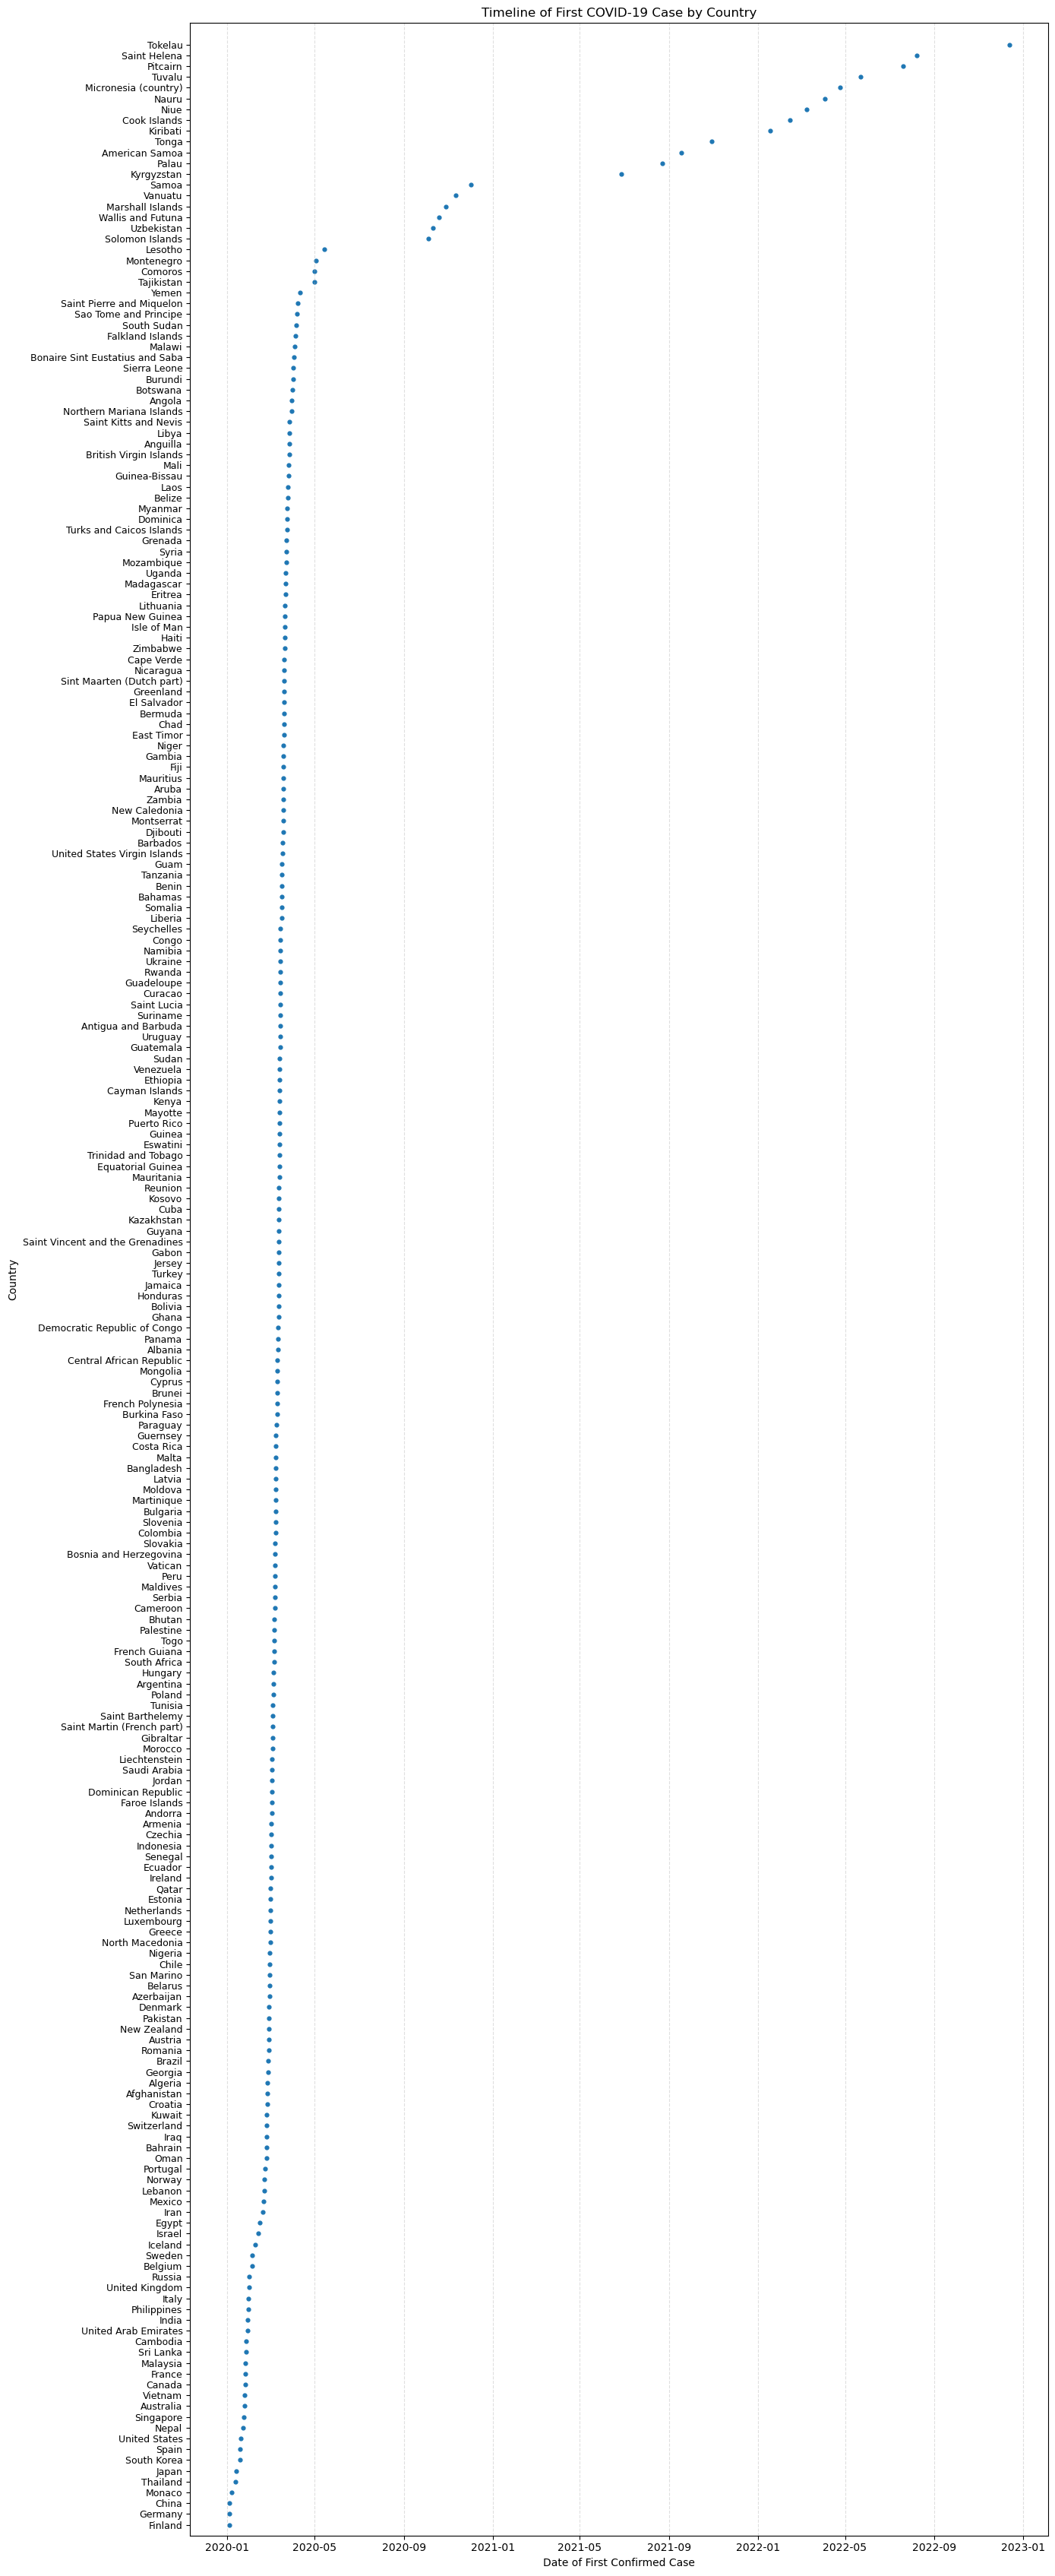

In [18]:
#Plot
plt.figure(figsize=(14,34))

plt.scatter(first_cases["first_case_date"],first_cases["country"],s=12)

plt.yticks(fontsize=9)  #smaller font for more spacing
plt.gca().set_ylim(-1,len(first_cases)+1)  #expand y-axis range

plt.xlabel("Date of First Confirmed Case")
plt.ylabel("Country")
plt.title("Timeline of First COVID-19 Case by Country")
plt.grid(axis='x',linestyle='--',alpha=0.4)

plt.tight_layout()
plt.show() 

The timeline shows that the majority of countries recorded their first COVID-19 case by mid-2020, but some remained case-free until 2021 or later. 

To quantify this trend, we calculate the proportion of countries in each continent that had not reported any cases prior to 2021.

In [19]:
#We merge back continent
first_cases=first_cases.merge(covid[["country","continent"]].drop_duplicates(),on="country",how="left")
first_cases.sort_values("first_case_date")

,country,first_case_date,continent
0,Finland,2020-01-04,Europe
1,Germany,2020-01-04,Europe
2,China,2020-01-04,Asia
3,Monaco,2020-01-08,Europe
4,Thailand,2020-01-13,Asia
...,...,...,...
226,Micronesia (country),2022-04-24,Oceania
227,Tuvalu,2022-05-22,Oceania
228,Pitcairn,2022-07-20,Oceania
229,Saint Helena,2022-08-08,Africa


In [20]:
#Filtering the countries that had their first covid case after 2021
late_countries=first_cases[first_cases["first_case_date"]>"2021-01-01"]
late_countries

,country,first_case_date,continent
218,Kyrgyzstan,2021-06-27,Asia
219,Palau,2021-08-22,Oceania
220,American Samoa,2021-09-18,Oceania
221,Tonga,2021-10-29,Oceania
222,Kiribati,2022-01-18,Oceania
223,Cook Islands,2022-02-14,Oceania
224,Niue,2022-03-09,Oceania
225,Nauru,2022-04-03,Oceania
226,Micronesia (country),2022-04-24,Oceania
227,Tuvalu,2022-05-22,Oceania


In [21]:
#Counting how many countries per continent
late_counts=late_countries.groupby("continent")["country"].nunique()
late_counts

#Total countries per continent
total_counts=first_cases.groupby("continent")["country"].nunique()
total_counts

#Percentage of countries per continent that remained covid free till 2021
percentage_late=(late_counts/total_counts*100).round(2)
percentage_late=percentage_late.fillna(0)
percentage_late.sort_values(ascending=False)

continent
Oceania          45.83
Asia              2.22
Africa            1.79
Europe            0.00
North America     0.00
South America     0.00
Name: country, dtype: float64

Almost half of the countries in Oceania did not report a COVID-19 case until 2021 or later, likely because many of them are remote island nations. Probably the ideal places to be when the next pandemic hits!

Now that we’ve explored the first reported case, let’s investigate when each country reached its peak number of new daily cases.

In [22]:
#We drop nan values
covid_c=covid.dropna(subset="new_cases")
covid_c[covid_c["total_cases"].isna()] #checking

,continent,country,date,total_cases,new_cases,total_deaths,new_deaths,population


In [23]:
country_peaks=compute_country_peaks(covid_c)

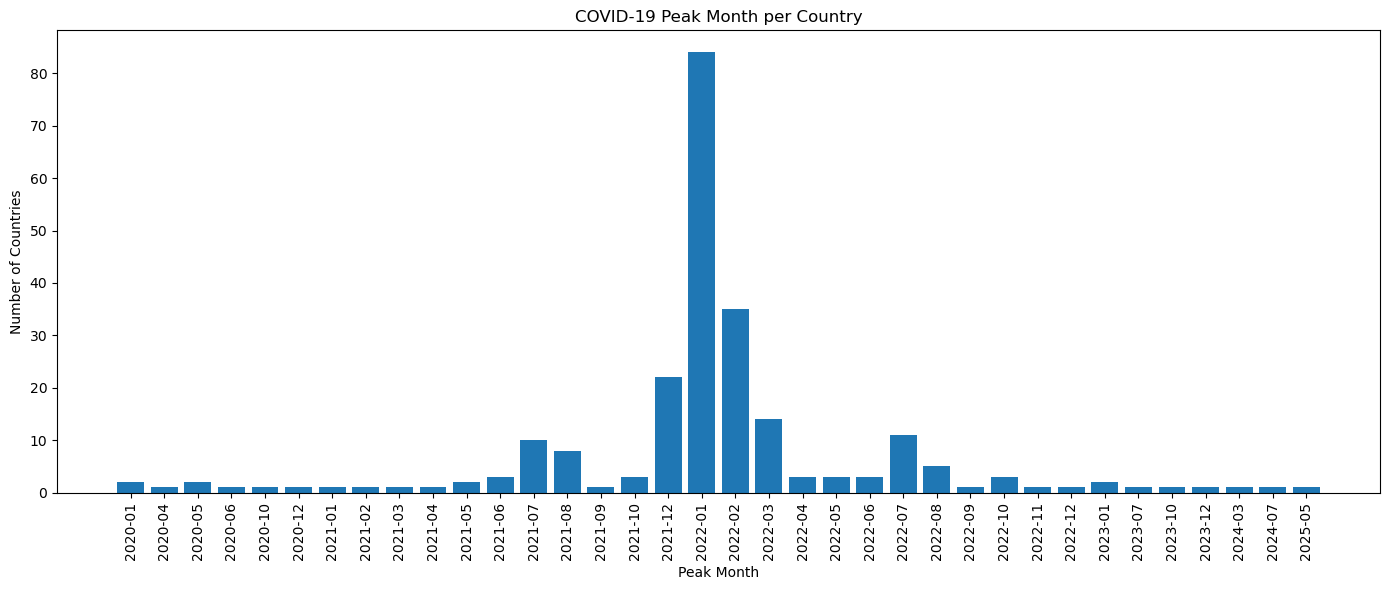

In [24]:
plot_peak_barchart(country_peaks)

From the chart, it’s clear that the highest concentration of peak waves occurred between December 2021 and March 2022. However, I’m curious to see which countries reached their peak as late as May 2025, so let’s take a closer look.

In [25]:
may_2025_peaks=country_peaks[(country_peaks["peak_date"].dt.year==2025)&(country_peaks["peak_date"].dt.month==5)]
print(may_2025_peaks)

      country  peak_date peak_month
207  Thailand 2025-05-27    2025-05


In [26]:
#Let's retrieve the relevant row from our dataset to check the number of the cases
covid_c[(covid_c["country"]=="Thailand")&(covid_c["date"]=="2025-05-27")]

,continent,country,date,total_cases,new_cases,total_deaths,new_deaths,population
470664,Asia,Thailand,2025-05-27,5081395.0,85933.0,34798.0,11.0,71735321.0


We also examine the countries that appear to have reached their peak in January 2020 to understand what these early values represent.

In [27]:
jan_2020_peaks=country_peaks[(country_peaks["peak_date"].dt.year==2020)&(country_peaks["peak_date"].dt.month==1)]
print(jan_2020_peaks)

          country  peak_date peak_month
152   North Korea 2020-01-04    2020-01
214  Turkmenistan 2020-01-04    2020-01


In [28]:
covid_c[covid_c["country"].isin(["North Korea","Turkmenistan"])]

,continent,country,date,total_cases,new_cases,total_deaths,new_deaths,population
344058,Asia,North Korea,2020-01-04,0.0,0.0,0.0,0.0,26328843.0
344059,Asia,North Korea,2020-01-05,0.0,0.0,0.0,0.0,26328843.0
344060,Asia,North Korea,2020-01-06,0.0,0.0,0.0,0.0,26328843.0
344061,Asia,North Korea,2020-01-07,0.0,0.0,0.0,0.0,26328843.0
344062,Asia,North Korea,2020-01-08,0.0,0.0,0.0,0.0,26328843.0
...,...,...,...,...,...,...,...,...
485551,Asia,Turkmenistan,2025-09-24,0.0,0.0,0.0,0.0,7230197.0
485552,Asia,Turkmenistan,2025-09-25,0.0,0.0,0.0,0.0,7230197.0
485553,Asia,Turkmenistan,2025-09-26,0.0,0.0,0.0,0.0,7230197.0
485554,Asia,Turkmenistan,2025-09-27,0.0,0.0,0.0,0.0,7230197.0


Both countries show zero values throughout the dataset, meaning no real data was ever recorded for them. Keeping them in the analysis creates misleading “peaks” in the bar chart, so it’s better to remove them from the dataset.

This is a good reminder that data cleaning is not a one-time step. Real-world datasets can contain missing or incorrect entries that only become visible once we start exploring and visualizing them. It’s important to stay attentive throughout the analysis and validate our findings as we go.

In [29]:
#Removing countries with 0 entries
valid_countries=covid_c.groupby("country")["new_cases"].sum()
valid_countries=valid_countries[valid_countries>0].index

covid_clean=covid_c[covid_c["country"].isin(valid_countries)].copy()

In [30]:
#Recalculation
country_peaks_clean=compute_country_peaks(covid_clean)

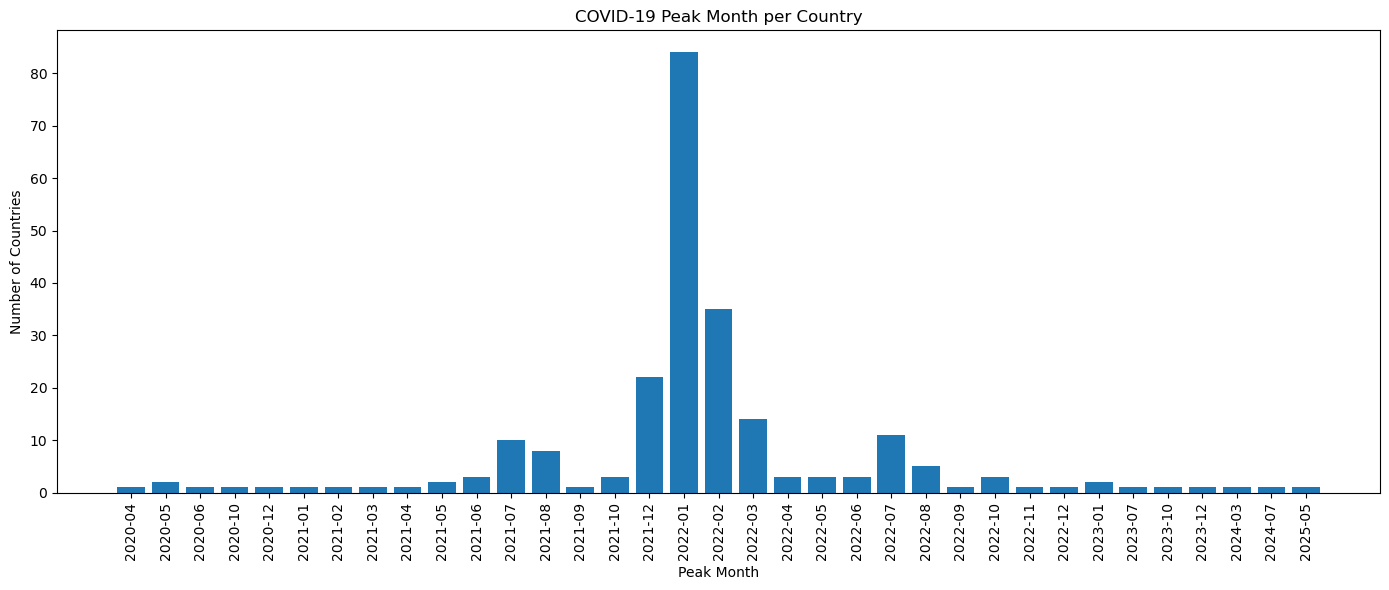

In [31]:
#Replot
plot_peak_barchart(country_peaks_clean)

Now that our peak chart is free of misleading entries, we can move on to another metric: the Case Fatality Ratio (CFR) for each country. Before calculating it, we ensure that there are no missing values in `total_deaths`, and then compute and visualize the ratio over time.

In [32]:
covid_clean[covid_clean["total_deaths"].isna()]

,continent,country,date,total_cases,new_cases,total_deaths,new_deaths,population


In [33]:
#Computing CFR per country
covid_clean["CFR"]=covid_clean["total_deaths"]/covid_clean["total_cases"]
covid_clean["CFR"]=covid_clean["CFR"].fillna(0) #replacing NaNs after division by 0

#Getting the percentage
covid_clean["CFR_percent"]=covid_clean["CFR"]*100

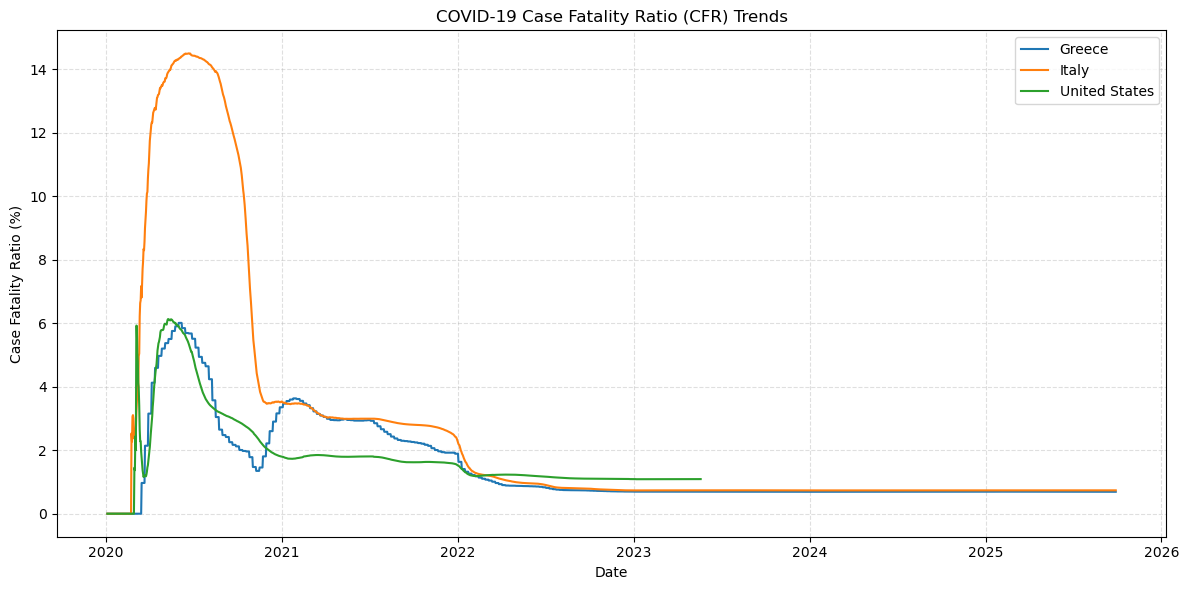

In [34]:
#CFR plot for specific countries, we pick the following
countries=["Greece","Italy","United States"]

plt.figure(figsize=(12,6))

for country in countries:
    subset=covid_clean[covid_clean["country"]==country]
    plt.plot(subset["date"],subset["CFR_percent"],label=country)

plt.xlabel("Date")
plt.ylabel("Case Fatality Ratio (%)")
plt.title("COVID-19 Case Fatality Ratio (CFR) Trends")
plt.legend()
plt.grid(linestyle="--",alpha=0.4)
plt.tight_layout()
plt.show()


We selected three countries—Italy, Greece, and the United States—to visualize their CFR trends. Italy shows a noticeably higher Case Fatality Ratio during 2020 compared with the other two, likely reflecting the severe impact of the early outbreak. It’s interesting to see how the CFR steadily drops in 2021 and continues declining through 2022, as healthcare systems adapt, testing becomes more widespread, and effective treatments become available.

CONCLUSION:

This project examined the timing of first confirmed COVID-19 cases, peak waves, and Case Fatality Ratio trends across countries worldwide. Most countries reported cases by mid-2020, while many island nations in Oceania remained unaffected until 2021. Peaks were concentrated around late 2021 to early 2022, and CFR declined steadily after 2020 as healthcare responses improved. Data issues encountered along the way showed the importance of ongoing cleaning and validation throughout the analysis. Overall, the project demonstrates how global patterns become visible when combining data exploration, visualization, and critical interpretation.
